In [1]:
# importing packages
import pyomo.environ as pyo
import numpy as np
from matplotlib import pyplot as plt
import math
import scipy.stats as stats
from scipy.optimize import fsolve, bisect, minimize
import pandas as pd
import conductivity as cd
from scipy.optimize import brute

# Determining the Best Cation Ratio for Three-Salt System Experiments

## Load the data

In [2]:
data = pd.read_csv("./Data/Three_salts_cation_ratio.csv")
NaCl_conc_raw = data["NaCl_conc"]
CaCl2_conc_raw = data["CaCl2_conc"]
LaCl3_conc_raw = data["LaCl3_conc"]

# number of data points
ndata = len(NaCl_conc_raw)

print(data)

   NaCl_conc  CaCl2_conc  LaCl3_conc
0          1           1           2
1          2           2           4
2          3           3           6
3          4           4           8
4          5           5          10
5          6           6          12
6          7           7          14
7          8           8          16
8          9           9          18
9         10          10          20


## MSA Transport model constants in SI units

In [3]:
# temperature in K
temp = 298.15

# diffusion coefficients at infinite dilution in m^2/s
Diff_Na = 1.334 * 10**(-9)
Diff_Cl = 2.032 * 10**(-9)
Diff_Ca = 0.792 * 10**(-9)
Diff_La = 0.619 * 10**(-9)
diffusion_coeff = [Diff_La, Diff_Ca, Diff_Na, Diff_Cl] 

# valencies
z_Na = 1
z_Cl = -1
z_Ca = 2
z_La = 3
valency = [z_La, z_Ca, z_Na, z_Cl]

# sensor voltage in V and probe distance in m
voltage = 25 * 10**(-3)
distance = 9 * 10**(-6)

# hard sphere diameters in m
sigma_Cl = 2 * 181 * 10**(-12)
sigma_Ca = 2 * 100 * 10**(-12)
sigma_La = 2 * 118 * 10**(-12)
sigma_Na = 2 * 102 * 10**(-12)
diameter = [sigma_La, sigma_Ca, sigma_Na, sigma_Cl]

# solvent viscosity in Pa.s
eta_msa = 0.89 * 10**(-3)

# relative permittivity
epsilon = 78.43

# limiting molar conductivity of ions in m^2.S/mol
lambda_0_Na_mol = 50.08 * 10**(-4)
lambda_0_Cl_mol = 76.31 * 10**(-4)
lambda_0_Ca_mol = 59.47 * 10**(-4)
lambda_0_La_mol = 69.7 * 10**(-4)
lambda_0_La_Ca_Na_Cl = [lambda_0_La_mol, lambda_0_Ca_mol, lambda_0_Na_mol, lambda_0_Cl_mol]

## Variant Shedlovsky model constants

In [4]:
# solvent viscosity in poise
eta_shed = 8.903*10**(-3)

# limiting equivalent conductivity of salts in cm^2.Siemen.equiv^(-1)
lambda_0_NaCl = 126.45 
lambda_0_CaCl2 = 135.85
lambda_0_LaCl3 = 145.9

# limiting equivalent conductivity of ions in cm^2.Siemen.equiv^(-1)
lambda_0_Na = 50.10 
lambda_0_Ca = 59.5
lambda_0_La = 69.7
lambda_0_Cl = 76.35

# distance from an ion within which no other ion can penetrate in cm
a_NaCl = 4*10**(-8)
a_CaCl2 = 4.31*10**(-8)
a_LaCl3 = 4.9*10**(-8)

## Validate the models with two-salt data

In [5]:
validation_data = pd.read_csv("./Data/NaCl_LaCl3_rearranged.csv")
NaCl_conc22 = validation_data["NaCl conc2"]
LaCl3_conc22 = validation_data["LaCl3 conc2"]
cond_exp = validation_data["Cal bulk cond2"]
print(cond_exp)

# diffusion coefficients, valencies, and hard sphere diameters of the two salts system
diffusion_coeff_2 = [Diff_La, Diff_Na, Diff_Cl]
valency_2 = [z_La, z_Na, z_Cl]
diameter_2 = [sigma_La, sigma_Na, sigma_Cl]
lambda_0_La_Na_Cl = [lambda_0_La_mol, lambda_0_Na_mol, lambda_0_Cl_mol]
a = (a_NaCl + a_LaCl3)/2

# evaluate the salts concentration in mM using the cation ratio
conc_NaCl_msa = [6*NaCl_conc_raw[i] for i in range(ndata)]

# evaluate the salts concentration in M using the cation ratio
conc_NaCl_shed = [conc_NaCl_msa[i]*10**(-3) for i in range(ndata)]
conc_LaCl3_shed = [LaCl3_conc_raw[i]*10**(-3) for i in range(ndata)]

# calculate the individual salt conductivity using the variant Shedlovsky model
variant_shed_cond_NaCl = cd.variant_shedlovsky(conc_NaCl_shed, temp, epsilon, eta_shed, lambda_0_NaCl, a, z_Na, z_Cl, 
                             lambda_0_Na, lambda_0_Cl)
variant_shed_cond_LaCl3 = cd.variant_shedlovsky(conc_LaCl3_shed, temp, epsilon, eta_shed, lambda_0_LaCl3, a, z_La, z_Cl, 
                             lambda_0_La, lambda_0_Cl)

# calculate the bulk conductivity using the variant Shedlovsky model
variant_shed_cond = [variant_shed_cond_NaCl[i] + variant_shed_cond_LaCl3[i] for i in range(ndata)] 

# calculate the bulk conductivity using the MSA transport model
msa_cond = cd.msa_transport(valency_2, diameter_2, diffusion_coeff_2, temp, eta_msa, epsilon, lambda_0_La_Na_Cl, LaCl3_conc_raw, conc_NaCl_msa)

sse = sum((msa_cond[i] - cond_exp[i])**2 for i in range(ndata))

err = [(msa_cond[i] - cond_exp[i])/msa_cond[i] for i in range(ndata)]
err_abs = [np.abs(err[i]) for i in range(ndata)]
print("MAPE",np.mean(err_abs))

print("The variant Shedlovsky:\n",variant_shed_cond)
print("MSA transport:\n",msa_cond)
print("SSE",sse)

0     1467.883721
1     2752.339767
2     4000.965581
3     5209.484651
4     6390.033023
5     7584.451163
6     8697.731163
7     9872.038140
8    10984.624650
9    12124.488370
Name: Cal bulk cond2, dtype: float64
Relaxation correction: [-0.17116259 -0.02670757 -0.09893508]
Hydrodynamic correction: [-0.40925151 -0.19314246 -0.1171157 ]
omega_bar: 293668709070.8091
Alpha: [0.0, 242876329097.13528, 388092787538.26306]
Mew: [0.5        0.16666667 0.33333333]
Transport number: [0.25596141 0.18387319 0.5601654 ]
Omega: [1.50335711e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.69629658 -0.98749428 -0.23296339]
 [ 0.78711213  1.6842391  -1.40795025]
 [ 0.51673602  0.63912188  1.0534202 ]]
MAPE 0.020757235331234646
The variant Shedlovsky:
 [1483.6887591090644, 2864.3562351305236, 4188.158227157195, 5470.507290133768, 6719.897842857054, 7941.830542973447, 9140.197040213245, 10317.912087125002, 11477.248024580847, 12620.030039097512]
MSA transport:
 [1430.8664142594344, 2732.0048114702, 3965.8

## Solve the Optimization Problem

### Validation of cation ratio with two-salt data

In [15]:
# create the objective function of the optimization problem
def SSE_validation(cation_ratio):
    """
    Calculates the sum of squared errors between the variant Shedlovsky and MSA Transport model

    Argument:
        cation_ratio: cation ratio of the salt"""

    # evaluate the salts concentration in mM using the cation ratio
    conc_NaCl = [cation_ratio*NaCl_conc_raw[i] for i in range(ndata)]

    # evaluate the salts concentration in M using the cation ratio
    conc_NaCl_shed = [conc_NaCl[i]*10**(-3) for i in range(ndata)]
    conc_LaCl3_shed = [LaCl3_conc_raw[i]*10**(-3) for i in range(ndata)]

    # calculate the individual salt conductivity using the variant Shedlovsky model
    variant_shed_cond_NaCl = cd.variant_shedlovsky(conc_NaCl_shed, temp, epsilon, eta_shed, lambda_0_NaCl, a, z_Na, z_Cl, 
                                 lambda_0_Na, lambda_0_Cl)
    variant_shed_cond_LaCl3 = cd.variant_shedlovsky(conc_LaCl3_shed, temp, epsilon, eta_shed, lambda_0_LaCl3, a, z_La, z_Cl, 
                                 lambda_0_La, lambda_0_Cl)

    # calculate the bulk conductivity using the variant Shedlovsky model
    variant_shed_cond = [variant_shed_cond_NaCl[i] + variant_shed_cond_LaCl3[i] for i in range(ndata)]

    # calculate the bulk conductivity using the MSA transport model
    msa_cond = cd.msa_transport(valency_2, diameter_2, diffusion_coeff_2, temp, eta_msa, epsilon, lambda_0_La_Na_Cl, LaCl3_conc_raw, conc_NaCl)

    # calculate the sum of squared errors between the variant Shedlovsky and MSA transport models
    sse = sum((msa_cond[i] - cond_exp[i])**2 for i in range(ndata))
    
    return sse

In [16]:
# Define bounds and step size for integers
ranges = (slice(1, 11, 1),)

# Run brute-force grid search
result = brute(SSE_validation, ranges=ranges, finish=None)

# Output
print("Best solution found for the cation ratio is:", result)
print("Objective value at best solution:", SSE_validation(result))

Relaxation correction: [-0.12637798 -0.01308509 -0.11019328]
Hydrodynamic correction: [-0.36243161 -0.17069429 -0.10443014]
omega_bar: 249407449467.97238
Alpha: [0.0, 296713649948.1031, 372366303979.31903]
Mew: [0.69230769 0.03846154 0.26923077]
Transport number: [0.41730337 0.04996255 0.53273408]
Omega: [1.50335711e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.44715366 -0.45169903 -0.31313326]
 [ 0.67150534  3.76294459 -2.32471958]
 [ 0.44084061  0.62394828  1.1373026 ]]
Relaxation correction: [-0.13744596 -0.01647846 -0.10720408]
Hydrodynamic correction: [-0.37274898 -0.17563275 -0.10724013]
omega_bar: 260788916222.98755
Alpha: [0.0, 280185123994.9613, 378474712351.47736]
Mew: [0.64285714 0.07142857 0.28571429]
Transport number: [0.37058471 0.08873811 0.54067718]
Omega: [1.50335711e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.50778913 -0.58944861 -0.27849707]
 [ 0.69964128  2.68345218 -1.89174574]
 [ 0.45931175  0.65539633  1.09955484]]
Relaxation correction: [-0.14726542 -0.01947212 

### Three-salt experiment cation ratio

In [8]:
a_Na_Ca_La = (a_NaCl + a_CaCl2 + a_LaCl3)/3

# create the objective function of the optimization problem
def SSE(cation_ratio):
    """
    Calculates the sum of squared errors between the variant Shedlovsky and MSA Transport model

    Argument:
        cation_ratio: list of the cation ratio of the salts"""

    # evaluate the salts concentration in mM using the cation ratio
    conc_NaCl = [cation_ratio[0]*NaCl_conc_raw[i] for i in range(ndata)]
    conc_CaCl2 = [cation_ratio[1]*CaCl2_conc_raw[i] for i in range(ndata)]

    # evaluate the salts concentration in M using the cation ratio
    conc_NaCl_shed = [conc_NaCl[i]*10**(-3) for i in range(ndata)]
    conc_CaCl2_shed = [conc_CaCl2[i]*10**(-3) for i in range(ndata)]
    conc_LaCl3_shed = [LaCl3_conc_raw[i]*10**(-3) for i in range(ndata)]

    # calculate the individual salt conductivity using the variant Shedlovsky model
    variant_shed_cond_NaCl = cd.variant_shedlovsky(conc_NaCl_shed, temp, epsilon, eta_shed, lambda_0_NaCl, a_Na_Ca_La, z_Na, z_Cl, 
                                 lambda_0_Na, lambda_0_Cl)
    variant_shed_cond_CaCl2 = cd.variant_shedlovsky(conc_CaCl2_shed, temp, epsilon, eta_shed, lambda_0_CaCl2, a_Na_Ca_La, z_Ca, z_Cl, 
                                 lambda_0_Ca, lambda_0_Cl)
    variant_shed_cond_LaCl3 = cd.variant_shedlovsky(conc_LaCl3_shed, temp, epsilon, eta_shed, lambda_0_LaCl3, a_Na_Ca_La, z_La, z_Cl, 
                                 lambda_0_La, lambda_0_Cl)

    # calculate the bulk conductivity using the variant Shedlovsky model
    variant_shed_cond = [variant_shed_cond_NaCl[i] + variant_shed_cond_CaCl2[i] + variant_shed_cond_LaCl3[i] for i in range(ndata)]

    # calculate the bulk conductivity using the MSA transport model
    msa_cond = cd.msa_transport(valency, diameter, diffusion_coeff, temp, eta_msa, epsilon, lambda_0_La_Ca_Na_Cl, LaCl3_conc_raw, conc_CaCl2, conc_NaCl)

    # calculate the sum of squared errors between the variant Shedlovsky and MSA transport models
    sse = sum((msa_cond[i] - variant_shed_cond[i])**2 for i in range(ndata))
    
    return sse

### Try Scipy minimize function

In [9]:
# initial guess of cation ratio
cation_ratio = [3, 3]

# solve the optimization problem
result = minimize(SSE, cation_ratio, bounds=[(1, 6), (1, 6)], method="L-BFGS-B")

# get the optimal cation ratio
opt_cation_ratio = result.x

# get the sse value at the optimal cation ratio
opt_sse = result.fun

print("The optimal cation ratio is:",opt_cation_ratio)
print("The objective function at the optimal is:",opt_sse)

Relaxation correction: [-0.18112685 -0.08424289 -0.02673774 -0.11149544]
Hydrodynamic correction: [-0.45658975 -0.36452458 -0.21590856 -0.12983571]
omega_bar: 278934675976.147
Alpha: [0.0, 172856559406.74725, 290001577279.39966, 375384664009.3576]
Mew: [0.375  0.25   0.0625 0.3125]
Transport number: [0.20211145 0.17239878 0.07259469 0.55289508]
Omega: [1.50335711e+11 1.92351992e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.63439298 -1.40422001 -0.47148858 -0.28703571]
 [ 1.27738542  1.83671414 -0.78767228 -0.41814481]
 [ 0.75838775  0.29334259  2.99475724 -2.03601072]
 [ 0.49787857  0.15702417  0.59697267  1.08616085]]
Relaxation correction: [-0.18112685 -0.08424289 -0.02673774 -0.11149544]
Hydrodynamic correction: [-0.45658975 -0.36452458 -0.21590856 -0.12983571]
omega_bar: 278934676030.23584
Alpha: [0.0, 172856559404.99518, 290001577203.6522, 375384664039.3267]
Mew: [0.375  0.25   0.0625 0.3125]
Transport number: [0.20211145 0.17239878 0.07259469 0.55289508]
Omega: [1.50335711e+11 1.9

### Use Scipy brute function (recommended)

In [10]:
# Define bounds and step size for integers
ranges = (slice(1, 7, 1), slice(1, 7, 1))

# Run brute-force grid search
opt_cation_ratio_int = brute(SSE, ranges=ranges, finish=None)

# get the sse value at the optimal cation ratio
opt_sse_int = SSE(opt_cation_ratio_int)

# Output
print("Best solution found for the cation ratio is:", opt_cation_ratio_int)
print("Objective value at best solution:", opt_sse_int)

Relaxation correction: [-0.1445827  -0.06104064 -0.01729417 -0.11187463]
Hydrodynamic correction: [-0.39288082 -0.31269002 -0.18527319 -0.11271869]
omega_bar: 257531873781.63416
Alpha: [0.0, 183116322854.86185, 302562938375.23364, 369832596041.1939]
Mew: [0.5625  0.125   0.03125 0.28125]
Transport number: [0.32836261 0.0933632  0.03931392 0.53896027]
Omega: [1.50335711e+11 1.92351992e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.50096741 -0.73185259 -0.38971956 -0.32406947]
 [ 1.17310458  2.95166376 -0.63026736 -0.4744769 ]
 [ 0.69647588  0.24133643  4.3137713  -2.50685801]
 [ 0.45723368  0.12503945  0.58025004  1.13755735]]
Relaxation correction: [-0.15852489 -0.06934379 -0.02048636 -0.11354644]
Hydrodynamic correction: [-0.41936697 -0.33419461 -0.19798597 -0.1198744 ]
omega_bar: 263090690417.29745
Alpha: [0.0, 177291329311.5861, 306198014447.22864, 368058818915.5673]
Mew: [0.47368421 0.21052632 0.02631579 0.28947368]
Transport number: [0.2706734  0.1539209  0.03240696 0.54299874]
Omeg

In [11]:
# evaluate the salts concentration in mM using the cation ratio
conc_NaCl = [opt_cation_ratio_int[0]*NaCl_conc_raw[i] for i in range(ndata)]
conc_CaCl2 = [opt_cation_ratio_int[1]*CaCl2_conc_raw[i] for i in range(ndata)]

# evaluate the salts concentration in M using the cation ratio
conc_NaCl_shed = [conc_NaCl[i]*10**(-3) for i in range(ndata)]
conc_CaCl2_shed = [conc_CaCl2[i]*10**(-3) for i in range(ndata)]
conc_LaCl3_shed = [LaCl3_conc_raw[i]*10**(-3) for i in range(ndata)]

# calculate the individual salt conductivity using the variant Shedlovsky model
variant_shed_cond_NaCl = cd.variant_shedlovsky(conc_NaCl_shed, temp, epsilon, eta_shed, lambda_0_NaCl, a_Na_Ca_La, z_Na, z_Cl, 
                             lambda_0_Na, lambda_0_Cl)
variant_shed_cond_CaCl2 = cd.variant_shedlovsky(conc_CaCl2_shed, temp, epsilon, eta_shed, lambda_0_CaCl2, a_Na_Ca_La, z_Ca, z_Cl, 
                             lambda_0_Ca, lambda_0_Cl)
variant_shed_cond_LaCl3 = cd.variant_shedlovsky(conc_LaCl3_shed, temp, epsilon, eta_shed, lambda_0_LaCl3, a_Na_Ca_La, z_La, z_Cl, 
                             lambda_0_La, lambda_0_Cl)

# calculate the bulk conductivity using the variant Shedlovsky model
variant_shed_cond = [variant_shed_cond_NaCl[i] + variant_shed_cond_CaCl2[i] + variant_shed_cond_LaCl3[i] for i in range(ndata)]

# calculate the bulk conductivity using the MSA transport model
msa_cond = cd.msa_transport(valency, diameter, diffusion_coeff, temp, eta_msa, epsilon, lambda_0_La_Ca_Na_Cl, LaCl3_conc_raw, conc_CaCl2, conc_NaCl)

residuals = [variant_shed_cond[i] - msa_cond[i] for i in range(ndata)]
residuals_percent = [residuals[i] / msa_cond[i] for i in range(ndata)]
print(residuals_percent)

Relaxation correction: [-0.1445827  -0.06104064 -0.01729417 -0.11187463]
Hydrodynamic correction: [-0.39288082 -0.31269002 -0.18527319 -0.11271869]
omega_bar: 257531873781.63416
Alpha: [0.0, 183116322854.86185, 302562938375.23364, 369832596041.1939]
Mew: [0.5625  0.125   0.03125 0.28125]
Transport number: [0.32836261 0.0933632  0.03931392 0.53896027]
Omega: [1.50335711e+11 1.92351992e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.50096741 -0.73185259 -0.38971956 -0.32406947]
 [ 1.17310458  2.95166376 -0.63026736 -0.4744769 ]
 [ 0.69647588  0.24133643  4.3137713  -2.50685801]
 [ 0.45723368  0.12503945  0.58025004  1.13755735]]
[0.03630518096655607, 0.04846823960077938, 0.05677566585342563, 0.063138303993008, 0.06828957576105844, 0.07260210723345392, 0.07629510670906375, 0.07950996490192402, 0.08234387405422286, 0.08486684562292339]


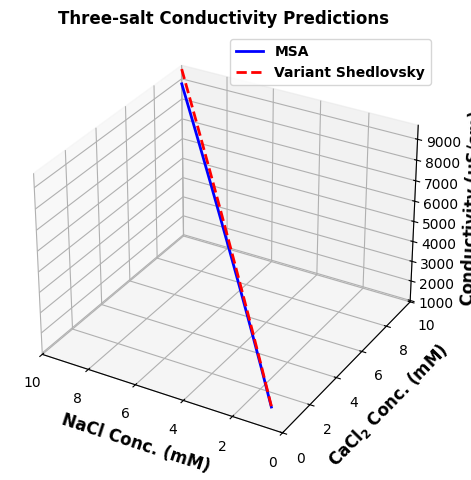

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

NaCl = np.array(conc_NaCl)
CaCl2 = np.array(conc_CaCl2)
LaCl3 = np.array(LaCl3_conc_raw)

# Plot lines for MSA conductivity
ax.plot3D(NaCl, CaCl2, msa_cond, color='blue', linewidth=2, label='MSA')

# Plot lines for Shedlovsky conductivity with different style
ax.plot3D(NaCl, CaCl2, variant_shed_cond, color='red', linestyle='--', linewidth=2, label='Variant Shedlovsky')

ax.set_xlim(10, 0)
ax.set_ylim(0, 10)
# ax.set_xlim(60, 0)
# ax.set_ylim(0, 60)

ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='z', labelsize=10)
ax.tick_params(direction="in",top=True, right=True)

ax.set_title('Three-salt Conductivity Predictions', fontsize=12,fontweight='bold')
ax.set_xlabel("NaCl Conc. (mM)", fontsize=12,fontweight='bold', labelpad=5)
ax.set_ylabel("CaC$\mathbf{l_2}$ Conc. (mM)", fontsize=12,fontweight='bold', labelpad=5)
ax.set_zlabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=12,fontweight='bold', labelpad=5)
ax.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(".\Three_salts\msa_shed_case_min.png")
# plt.savefig(".\Three_salts\msa_shed_case_max.png")
plt.show()

### Determine the best cation ratio given a desired ionic strength experiment

In [13]:
# data in mM
ionic_strength = 100
conc_la = 5

# cation ratio
na_la_ratio = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
residuals_percent = []
cation_ratio = []

for ratio in na_la_ratio:
    conc_na = ratio * conc_la
    conc_ca = (ionic_strength - 
               0.5 * (conc_na * z_Na**2 + conc_na * z_Cl**2 + conc_la * z_La**2 + conc_la * z_La * z_Cl**2)) / (0.5 * (z_Ca**2 + z_Ca * z_Cl**2))

    if conc_ca % conc_la == 0:
        print("The concentration of NaCl is:",conc_na)
        print("The concentration of CaCl2 is:",conc_ca)
        
        # get the ratio of Ca and La
        ca_la_ratio = conc_ca / conc_la
        cation_ratio.append((ratio, ca_la_ratio, 1))

        # evaluate the salts concentration in M using the cation ratio
        conc_NaCl_shed = [conc_na * 10**(-3)]
        conc_CaCl2_shed = [conc_ca * 10**(-3)]
        conc_LaCl3_shed = [conc_la * 10**(-3)]
    
        # calculate the individual salt conductivity using the variant Shedlovsky model
        variant_shed_cond_NaCl = cd.variant_shedlovsky(conc_NaCl_shed, temp, epsilon, eta_shed, lambda_0_NaCl, a_Na_Ca_La, z_Na, z_Cl, 
                                     lambda_0_Na, lambda_0_Cl)
        variant_shed_cond_CaCl2 = cd.variant_shedlovsky(conc_CaCl2_shed, temp, epsilon, eta_shed, lambda_0_CaCl2, a_Na_Ca_La, z_Ca, z_Cl, 
                                     lambda_0_Ca, lambda_0_Cl)
        variant_shed_cond_LaCl3 = cd.variant_shedlovsky(conc_LaCl3_shed, temp, epsilon, eta_shed, lambda_0_LaCl3, a_Na_Ca_La, z_La, z_Cl, 
                                     lambda_0_La, lambda_0_Cl)
    
        # get the number of data
        ndata_all = len(variant_shed_cond_NaCl)
    
        # calculate the bulk conductivity using the variant Shedlovsky model
        variant_shed_cond = [variant_shed_cond_NaCl[i] + variant_shed_cond_CaCl2[i] + variant_shed_cond_LaCl3[i] for i in range(ndata_all)]
    
        # calculate the bulk conductivity using the MSA transport model
        msa_cond = cd.msa_transport(valency, diameter, diffusion_coeff, temp, eta_msa, epsilon, lambda_0_La_Ca_Na_Cl, 
                                    [conc_la], [conc_ca], [conc_na])

        # calculate the residuals between the MSA transport and variant Shedlovksy models
        residuals = [variant_shed_cond[i] - msa_cond[i] for i in range(ndata_all)]
        residuals_per = [100 * residuals[i] / msa_cond[i] for i in range(ndata_all)]
        abs_residuals_per = [np.abs(residuals_per[i]) for i in range(ndata_all)]
        residuals_percent.append(np.mean(abs_residuals_per))

print(f"The cation ratios are:",cation_ratio)
print(f"The residuals are:",residuals_percent)

The concentration of NaCl is: 10
The concentration of CaCl2 is: 20.0
Relaxation correction: [-0.15603642 -0.07440387 -0.02423714 -0.08552419]
Hydrodynamic correction: [-0.32825731 -0.26043061 -0.1543648  -0.09507259]
omega_bar: 287356147364.45593
Alpha: [0.0, 163218629345.9894, 297311626152.761, 372369995822.512]
Mew: [0.225 0.4   0.05  0.325]
Transport number: [0.11771293 0.26775414 0.05637374 0.55815919]
Omega: [1.50335711e+11 1.92351992e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.70201326 -2.31156368 -0.40676451 -0.29934941]
 [ 1.33023511  1.15332303 -0.66625367 -0.43725983]
 [ 0.78976477  0.25691287  3.48002714 -2.22225879]
 [ 0.51847746  0.14131377  0.56622193  1.08729382]]
The concentration of NaCl is: 25
The concentration of CaCl2 is: 15.0
Relaxation correction: [-0.16367275 -0.08077667 -0.02736277 -0.07946372]
Hydrodynamic correction: [-0.3276836  -0.25997589 -0.15409525 -0.0949057 ]
omega_bar: 304757688099.0585
Alpha: [0.0, 165127186239.83066, 270085405210.12726, 382628449516

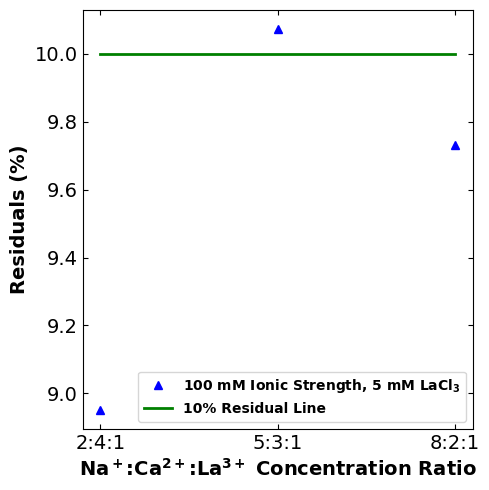

In [14]:
# making plot of residuals of calculated specific conductivity
x_labels = [f"{int(a)}:{int(b)}:{int(c)}" for a, b, c in cation_ratio]
ten_percent_resid = np.array([10 for _ in range(len(cation_ratio))])
fig = plt.figure(figsize=(5, 5))
# plt.plot(x_labels, residuals_percent, "^", color="blue", label="250 mM Ionic Strength, 10 mM LaCl$\mathbf{_3}$")
plt.plot(x_labels, residuals_percent, "^", color="blue", label="100 mM Ionic Strength, 5 mM LaCl$\mathbf{_3}$")
plt.plot(x_labels, ten_percent_resid, "-", color="green", linewidth=2, label="10% Residual Line")
plt.xlabel("Na$\mathbf{^+}$:Ca$\mathbf{^{2+}}$:La$\mathbf{^{3+}}$ Concentration Ratio", fontsize=14,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(".\Three_salts\msa_var_shed_na_ca_la_resid100.png")
# plt.savefig(".\Three_salts\msa_var_shed_na_ca_la_resid250.png")
plt.show()